In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ML
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

# Carregar dataset de features
df = pd.read_parquet('../data/processed/dataset_features_v2.parquet')
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').reset_index(drop=True)

print(f"✅ Dataset carregado: {df.shape}")
print(f"Período: {df['data'].min().date()} → {df['data'].max().date()}")
print(f"\nTarget (casos) — estatísticas:")
print(df['casos'].describe().round(2))

✅ Dataset carregado: (2242, 55)
Período: 2018-02-12 → 2024-12-28

Target (casos) — estatísticas:
count    2242.00
mean       66.45
std        77.43
min         1.00
25%        15.00
50%        35.00
75%        84.00
max       440.00
Name: casos, dtype: float64


In [2]:
# ============================================================
# PREPARAÇÃO DOS DADOS
# ============================================================

# Colunas a excluir do modelo
EXCLUIR = ['data', 'casos', 'casos_acum_ano']

# Features e target
feature_cols = [c for c in df.columns if c not in EXCLUIR]
X = df[feature_cols]
y = df['casos']

print(f"Features: {len(feature_cols)}")
print(f"Target: casos (regressão)")

# Verificar NaNs
print(f"\nNaNs em X: {X.isnull().sum().sum()}")
print(f"NaNs em y: {y.isnull().sum()}")

# TimeSeriesSplit — 5 folds respeitando ordem temporal
tscv = TimeSeriesSplit(n_splits=5)

print(f"\n📅 TimeSeriesSplit — 5 folds:")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    train_start = df['data'].iloc[train_idx[0]].date()
    train_end = df['data'].iloc[train_idx[-1]].date()
    val_start = df['data'].iloc[val_idx[0]].date()
    val_end = df['data'].iloc[val_idx[-1]].date()
    print(f"  Fold {fold}: treino {train_start}→{train_end} | val {val_start}→{val_end}")

Features: 52
Target: casos (regressão)

NaNs em X: 41
NaNs em y: 0

📅 TimeSeriesSplit — 5 folds:
  Fold 1: treino 2018-02-12→2019-04-09 | val 2019-04-10→2020-09-02
  Fold 2: treino 2018-02-12→2020-09-02 | val 2020-09-03→2021-10-12
  Fold 3: treino 2018-02-12→2021-10-12 | val 2021-10-13→2022-12-13
  Fold 4: treino 2018-02-12→2022-12-13 | val 2022-12-14→2023-12-21
  Fold 5: treino 2018-02-12→2023-12-21 | val 2023-12-22→2024-12-28


In [3]:
# Verificar quais colunas têm NaN
nans = X.isnull().sum()
print("Colunas com NaN:")
print(nans[nans > 0])

Colunas com NaN:
radiacao_lag_28d    28
radiacao_mm_14d     13
dtype: int64


In [4]:
# Preencher NaNs com forward fill (valor anterior)
X = X.ffill().bfill()
print(f"NaNs após tratamento: {X.isnull().sum().sum()}")

# Confirmar tipos
print(f"\nTipos de dados:")
print(X.dtypes.value_counts())

NaNs após tratamento: 0

Tipos de dados:
float64    43
int64       5
int32       4
Name: count, dtype: int64


In [5]:
# Remover linhas com NaN — mais defensável academicamente
X_clean = X.dropna()
y_clean = y[X_clean.index]
df_clean = df.loc[X_clean.index].reset_index(drop=True)
X_clean = X_clean.reset_index(drop=True)
y_clean = y_clean.reset_index(drop=True)

print(f"Registros antes: {len(X):,}")
print(f"Registros após remoção: {len(X_clean):,}")
print(f"Removidos: {len(X) - len(X_clean)} registros")
print(f"Período final: {df_clean['data'].min().date()} → {df_clean['data'].max().date()}")

Registros antes: 2,242
Registros após remoção: 2,242
Removidos: 0 registros
Período final: 2018-02-12 → 2024-12-28


In [6]:
# ============================================================
# MODELO BASELINE — XGBoost
# ============================================================

from xgboost import XGBRegressor

# Configuração do modelo baseline — parâmetros conservadores
modelo_baseline = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Validação com TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
resultados = []

print("🔄 Treinando com TimeSeriesSplit...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    modelo_baseline.fit(X_train, y_train,
                       eval_set=[(X_val, y_val)],
                       verbose=False)

    y_pred = modelo_baseline.predict(X_val)
    y_pred = np.clip(y_pred, 0, None)  # sem valores negativos

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    resultados.append({
        'fold': fold,
        'train_size': len(train_idx),
        'val_size': len(val_idx),
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    })

    print(f"Fold {fold}: MAE={mae:.1f} | RMSE={rmse:.1f} | R²={r2:.3f}")

# Resumo
res_df = pd.DataFrame(resultados)
print(f"\n📊 MÉDIA DOS FOLDS:")
print(f"  MAE:  {res_df['mae'].mean():.1f} ± {res_df['mae'].std():.1f}")
print(f"  RMSE: {res_df['rmse'].mean():.1f} ± {res_df['rmse'].std():.1f}")
print(f"  R²:   {res_df['r2'].mean():.3f} ± {res_df['r2'].std():.3f}")

🔄 Treinando com TimeSeriesSplit...

Fold 1: MAE=67.5 | RMSE=106.5 | R²=-0.437
Fold 2: MAE=12.2 | RMSE=17.5 | R²=0.770
Fold 3: MAE=20.2 | RMSE=33.1 | R²=0.740
Fold 4: MAE=15.9 | RMSE=25.4 | R²=0.862
Fold 5: MAE=25.5 | RMSE=42.9 | R²=0.848

📊 MÉDIA DOS FOLDS:
  MAE:  28.3 ± 22.5
  RMSE: 45.1 ± 35.6
  R²:   0.557 ± 0.558


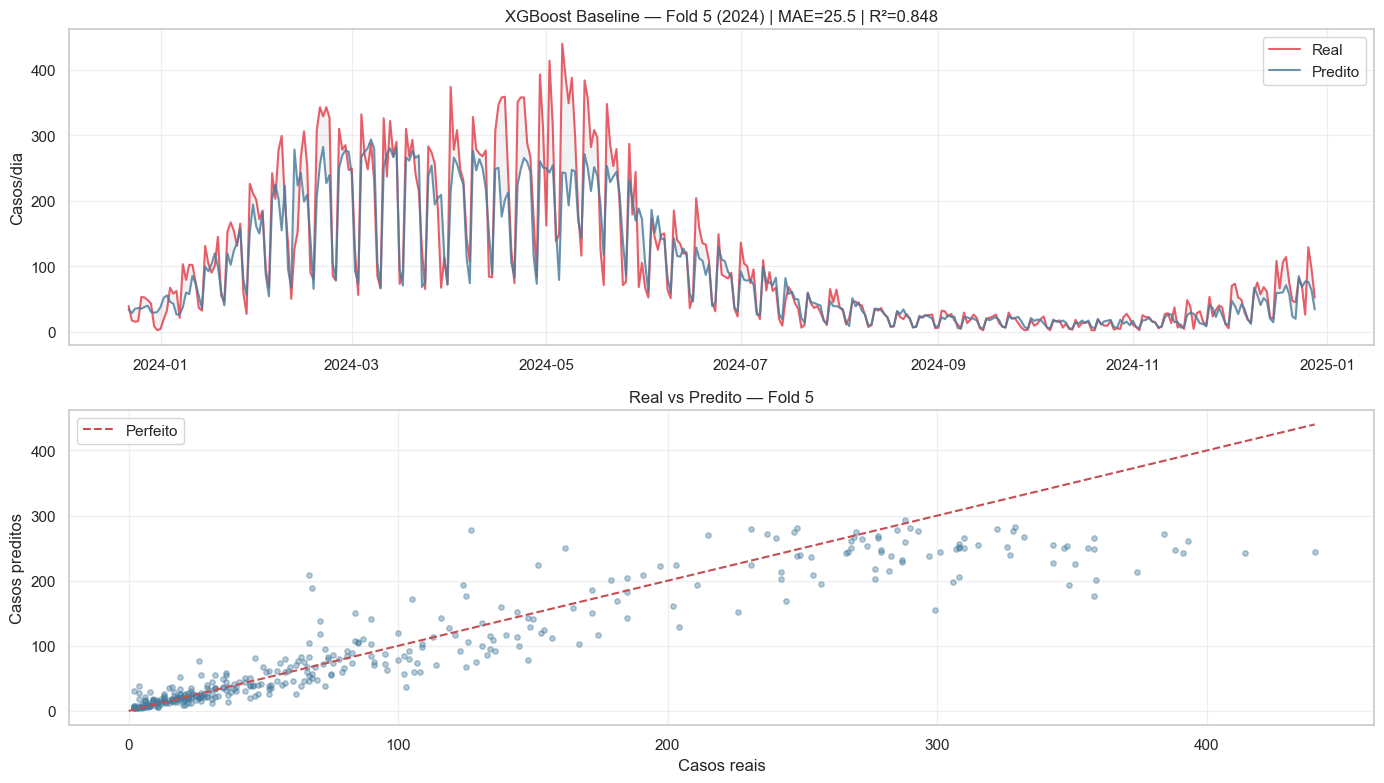

✅ Gráfico salvo!


In [7]:
# Retreinar no Fold 5 e visualizar predições
folds = list(tscv.split(X))
train_idx, val_idx = folds[4]  # Fold 5

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

modelo_baseline.fit(X_train, y_train, verbose=False)
y_pred = np.clip(modelo_baseline.predict(X_val), 0, None)

datas_val = df['data'].iloc[val_idx]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 1 — Real vs Predito
axes[0].plot(datas_val, y_val.values, color='#e63946', 
             linewidth=1.5, label='Real', alpha=0.8)
axes[0].plot(datas_val, y_pred, color='#457b9d', 
             linewidth=1.5, label='Predito', alpha=0.8)
axes[0].fill_between(datas_val, y_val.values, y_pred, alpha=0.1, color='gray')
axes[0].set_title(f'XGBoost Baseline — Fold 5 (2024) | MAE={mean_absolute_error(y_val, y_pred):.1f} | R²={r2_score(y_val, y_pred):.3f}', fontsize=12)
axes[0].set_ylabel('Casos/dia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2 — Scatter real vs predito
axes[1].scatter(y_val, y_pred, alpha=0.4, color='#457b9d', s=15)
max_val = max(y_val.max(), y_pred.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfeito')
axes[1].set_xlabel('Casos reais')
axes[1].set_ylabel('Casos preditos')
axes[1].set_title('Real vs Predito — Fold 5')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/fig11_xgboost_baseline_fold5.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

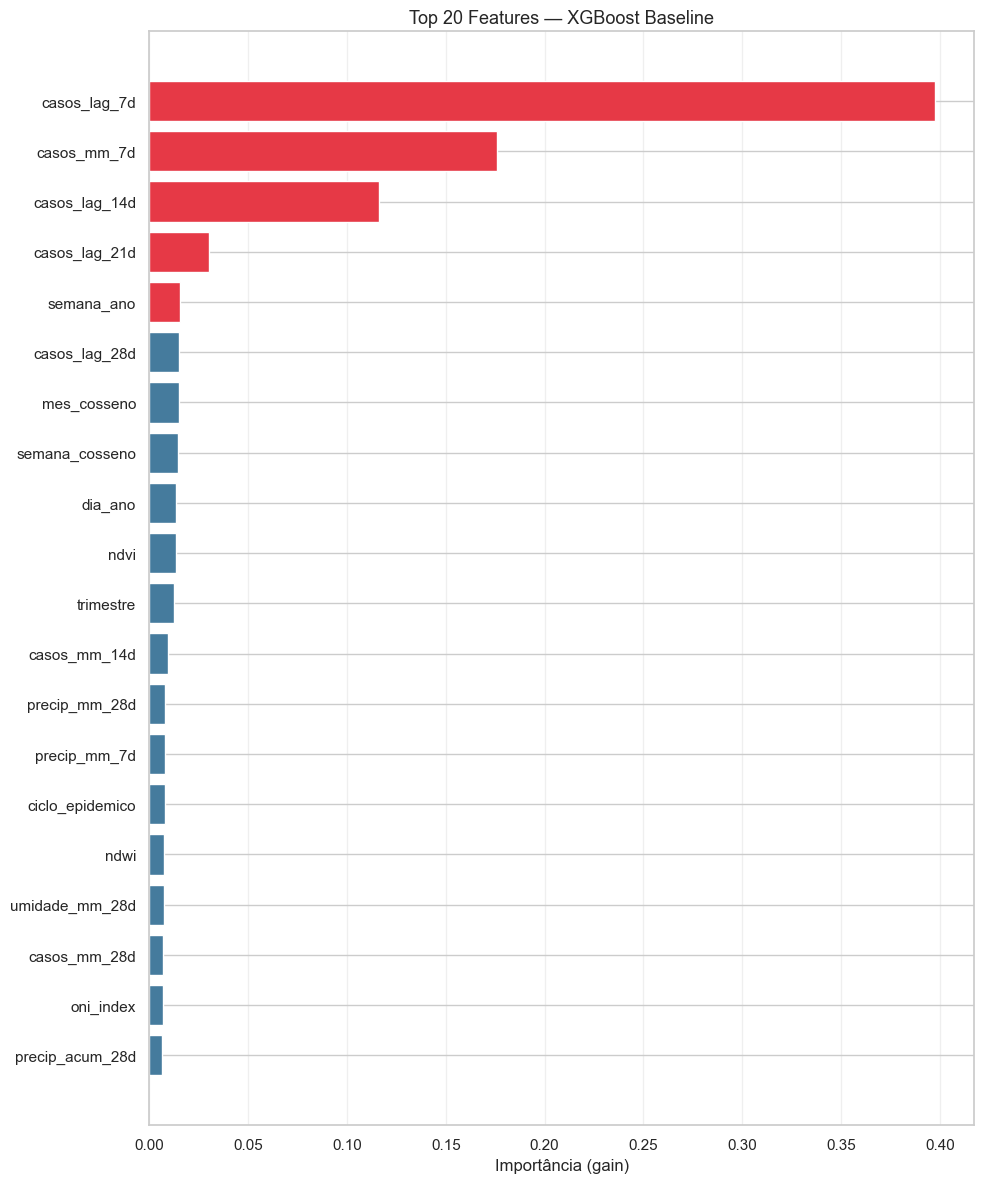

✅ Gráfico salvo!

Top 10 features:
       feature  importancia
  casos_lag_7d     0.397422
   casos_mm_7d     0.176158
 casos_lag_14d     0.116006
 casos_lag_21d     0.030426
    semana_ano     0.015378
 casos_lag_28d     0.015243
   mes_cosseno     0.014846
semana_cosseno     0.014314
       dia_ano     0.013394
          ndvi     0.013257


In [8]:
# Importância das features — XGBoost
importancias = pd.DataFrame({
    'feature': X.columns,
    'importancia': modelo_baseline.feature_importances_
}).sort_values('importancia', ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
top20 = importancias.head(20)
cores = ['#e63946' if i < 5 else '#457b9d' for i in range(len(top20))]
ax.barh(top20['feature'], top20['importancia'], color=cores)
ax.invert_yaxis()
ax.set_title('Top 20 Features — XGBoost Baseline', fontsize=13)
ax.set_xlabel('Importância (gain)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../reports/fig12_feature_importance_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")
print("\nTop 10 features:")
print(importancias.head(10).to_string(index=False))

⏳ Calculando SHAP values...


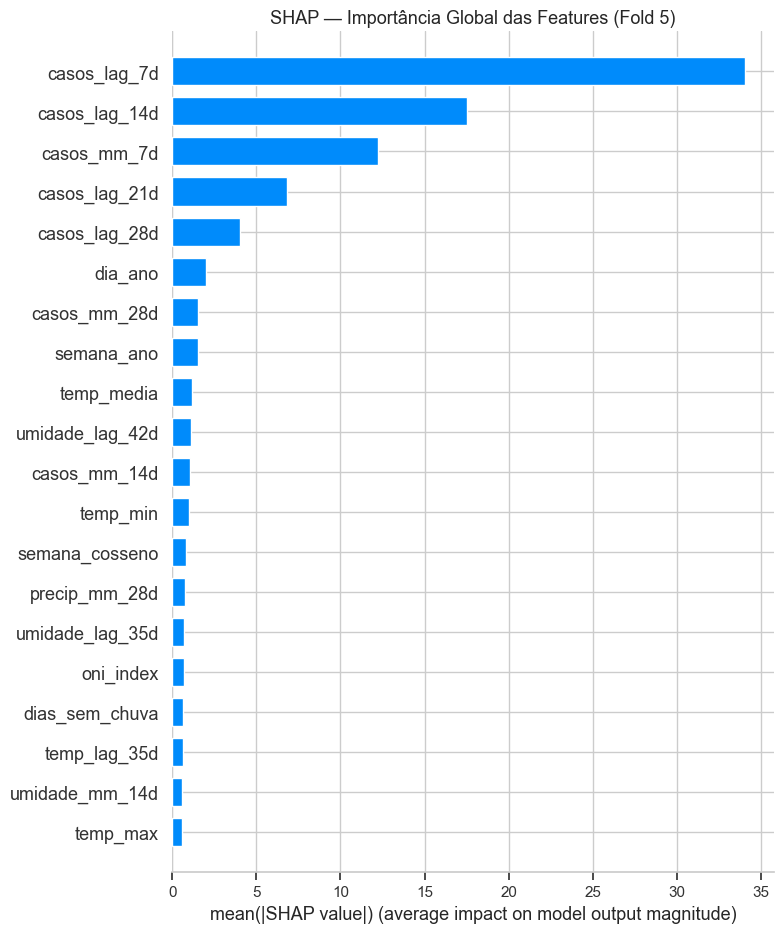

✅ SHAP salvo!


In [9]:
import shap

# SHAP values — interpretabilidade
print("⏳ Calculando SHAP values...")
explainer = shap.TreeExplainer(modelo_baseline)
shap_values = explainer.shap_values(X_val)

# Summary plot
plt.figure(figsize=(10, 12))
shap.summary_plot(shap_values, X_val, plot_type='bar', 
                  max_display=20, show=False)
plt.title('SHAP — Importância Global das Features (Fold 5)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/fig13_shap_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP salvo!")

In [10]:
import joblib
from pathlib import Path

# Salvar modelo baseline
Path('../models').mkdir(exist_ok=True)
joblib.dump(modelo_baseline, '../models/xgboost_baseline.pkl')

# Salvar métricas
res_df.to_csv('../reports/metricas_xgboost_baseline.csv', index=False)

print("✅ Modelo salvo em models/xgboost_baseline.pkl")
print("✅ Métricas salvas em reports/metricas_xgboost_baseline.csv")
print(f"\n📊 Resumo final XGBoost Baseline:")
print(f"  Folds 2-5 (excluindo fold 1 com dados insuficientes):")
res_sem_fold1 = res_df[res_df['fold'] > 1]
print(f"  MAE:  {res_sem_fold1['mae'].mean():.1f} ± {res_sem_fold1['mae'].std():.1f}")
print(f"  RMSE: {res_sem_fold1['rmse'].mean():.1f} ± {res_sem_fold1['rmse'].std():.1f}")
print(f"  R²:   {res_sem_fold1['r2'].mean():.3f} ± {res_sem_fold1['r2'].std():.3f}")

✅ Modelo salvo em models/xgboost_baseline.pkl
✅ Métricas salvas em reports/metricas_xgboost_baseline.csv

📊 Resumo final XGBoost Baseline:
  Folds 2-5 (excluindo fold 1 com dados insuficientes):
  MAE:  18.5 ± 5.7
  RMSE: 29.7 ± 10.8
  R²:   0.805 ± 0.059


In [3]:
from lightgbm import LGBMRegressor

# Modelo LightGBM — parâmetros equivalentes ao XGBoost para comparação justa
modelo_lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

resultados_lgbm = []

print("🔄 Treinando LightGBM com TimeSeriesSplit...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    modelo_lgbm.fit(X_train, y_train)
    y_pred = np.clip(modelo_lgbm.predict(X_val), 0, None)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    resultados_lgbm.append({
        'fold': fold, 'mae': mae, 'rmse': rmse, 'r2': r2
    })
    print(f"Fold {fold}: MAE={mae:.1f} | RMSE={rmse:.1f} | R²={r2:.3f}")

res_lgbm = pd.DataFrame(resultados_lgbm)
res_sem_fold1_lgbm = res_lgbm[res_lgbm['fold'] > 1]

print(f"\n📊 LightGBM — Folds 2-5:")
print(f"  MAE:  {res_sem_fold1_lgbm['mae'].mean():.1f} ± {res_sem_fold1_lgbm['mae'].std():.1f}")
print(f"  RMSE: {res_sem_fold1_lgbm['rmse'].mean():.1f} ± {res_sem_fold1_lgbm['rmse'].std():.1f}")
print(f"  R²:   {res_sem_fold1_lgbm['r2'].mean():.3f} ± {res_sem_fold1_lgbm['r2'].std():.3f}")

# Comparação direta
print(f"\n🏆 COMPARAÇÃO XGBoost vs LightGBM (Folds 2-5):")
print(f"{'Métrica':<10} {'XGBoost':>12} {'LightGBM':>12}")
print(f"{'MAE':<10} {res_sem_fold1['mae'].mean():>12.1f} {res_sem_fold1_lgbm['mae'].mean():>12.1f}")
print(f"{'RMSE':<10} {res_sem_fold1['rmse'].mean():>12.1f} {res_sem_fold1_lgbm['rmse'].mean():>12.1f}")
print(f"{'R²':<10} {res_sem_fold1['r2'].mean():>12.3f} {res_sem_fold1_lgbm['r2'].mean():>12.3f}")

🔄 Treinando LightGBM com TimeSeriesSplit...

Fold 1: MAE=62.7 | RMSE=100.8 | R²=-0.287
Fold 2: MAE=12.1 | RMSE=18.7 | R²=0.739
Fold 3: MAE=19.2 | RMSE=31.2 | R²=0.769
Fold 4: MAE=15.7 | RMSE=26.2 | R²=0.854
Fold 5: MAE=25.4 | RMSE=42.1 | R²=0.853

📊 LightGBM — Folds 2-5:
  MAE:  18.1 ± 5.7
  RMSE: 29.6 ± 9.8
  R²:   0.804 ± 0.059

🏆 COMPARAÇÃO XGBoost vs LightGBM (Folds 2-5):
Métrica         XGBoost     LightGBM
MAE                18.5         18.1
RMSE               29.7         29.6
R²                0.805        0.804


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

# Carregar dataset
df = pd.read_parquet('../data/processed/dataset_features_v2.parquet')
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').reset_index(drop=True)

# Features e target
EXCLUIR = ['data', 'casos', 'casos_acum_ano']
feature_cols = [c for c in df.columns if c not in EXCLUIR]
X = df[feature_cols].ffill().bfill()
y = df['casos']

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Recarregar métricas XGBoost já calculadas
res_df = pd.read_csv('../reports/metricas_xgboost_baseline.csv')
res_sem_fold1 = res_df[res_df['fold'] > 1]

print(f"✅ Tudo recarregado! X={X.shape}, y={y.shape}")

✅ Tudo recarregado! X=(2242, 52), y=(2242,)


In [4]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Usar apenas Folds 2-5 para otimização (excluir Fold 1 com dados insuficientes)
folds_lista = list(tscv.split(X))
folds_otimizacao = folds_lista[1:]  # Folds 2 a 5

def objetivo_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'random_state': 42,
        'n_jobs': -1
    }
    maes = []
    for train_idx, val_idx in folds_otimizacao:
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        modelo = XGBRegressor(**params)
        modelo.fit(X_train, y_train, verbose=False)
        y_pred = np.clip(modelo.predict(X_val), 0, None)
        maes.append(mean_absolute_error(y_val, y_pred))
    return np.mean(maes)

print("🔍 Otimizando XGBoost com Optuna (50 trials)...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objetivo_xgb, n_trials=50, show_progress_bar=True)

print(f"\n✅ Melhor MAE XGBoost: {study_xgb.best_value:.2f}")
print(f"Melhores parâmetros:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

🔍 Otimizando XGBoost com Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Melhor MAE XGBoost: 17.31
Melhores parâmetros:
  n_estimators: 424
  learning_rate: 0.016979041057695085
  max_depth: 6
  subsample: 0.6524683964815008
  colsample_bytree: 0.9342549570363141
  min_child_weight: 10
  gamma: 0.7413685538545239


In [5]:
def objetivo_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    maes = []
    for train_idx, val_idx in folds_otimizacao:
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        modelo = LGBMRegressor(**params)
        modelo.fit(X_train, y_train)
        y_pred = np.clip(modelo.predict(X_val), 0, None)
        maes.append(mean_absolute_error(y_val, y_pred))
    return np.mean(maes)

print("🔍 Otimizando LightGBM com Optuna (50 trials)...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objetivo_lgbm, n_trials=50, show_progress_bar=True)

print(f"\n✅ Melhor MAE LightGBM: {study_lgbm.best_value:.2f}")
print(f"Melhores parâmetros:")
for k, v in study_lgbm.best_params.items():
    print(f"  {k}: {v}")

🔍 Otimizando LightGBM com Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Melhor MAE LightGBM: 17.44
Melhores parâmetros:
  n_estimators: 220
  learning_rate: 0.02481161808481769
  max_depth: 5
  subsample: 0.6870905613878383
  colsample_bytree: 0.7552269312052796
  min_child_samples: 49
  num_leaves: 58


In [6]:
# Treinar modelos otimizados com todos os folds
print("🏋️ Treinando modelos otimizados...\n")

# XGBoost otimizado
modelo_xgb_opt = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)

# LightGBM otimizado  
modelo_lgbm_opt = LGBMRegressor(**study_lgbm.best_params, random_state=42, 
                                 n_jobs=-1, verbose=-1)

resultados_comparacao = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # XGBoost
    modelo_xgb_opt.fit(X_train, y_train, verbose=False)
    pred_xgb = np.clip(modelo_xgb_opt.predict(X_val), 0, None)

    # LightGBM
    modelo_lgbm_opt.fit(X_train, y_train)
    pred_lgbm = np.clip(modelo_lgbm_opt.predict(X_val), 0, None)

    for nome, preds in [('XGBoost_opt', pred_xgb), ('LightGBM_opt', pred_lgbm)]:
        resultados_comparacao.append({
            'modelo': nome,
            'fold': fold,
            'mae': mean_absolute_error(y_val, preds),
            'rmse': np.sqrt(mean_squared_error(y_val, preds)),
            'r2': r2_score(y_val, preds)
        })

comp_df = pd.DataFrame(resultados_comparacao)
comp_sem_fold1 = comp_df[comp_df['fold'] > 1]

print("🏆 COMPARAÇÃO FINAL — Modelos Otimizados (Folds 2-5):\n")
for modelo in ['XGBoost_opt', 'LightGBM_opt']:
    m = comp_sem_fold1[comp_sem_fold1['modelo'] == modelo]
    print(f"{modelo}:")
    print(f"  MAE:  {m['mae'].mean():.2f} ± {m['mae'].std():.2f}")
    print(f"  RMSE: {m['rmse'].mean():.2f} ± {m['rmse'].std():.2f}")
    print(f"  R²:   {m['r2'].mean():.3f} ± {m['r2'].std():.3f}")
    print()

🏋️ Treinando modelos otimizados...

🏆 COMPARAÇÃO FINAL — Modelos Otimizados (Folds 2-5):

XGBoost_opt:
  MAE:  17.31 ± 5.54
  RMSE: 28.23 ± 9.69
  R²:   0.823 ± 0.047

LightGBM_opt:
  MAE:  17.44 ± 5.42
  RMSE: 27.83 ± 9.78
  R²:   0.830 ± 0.040



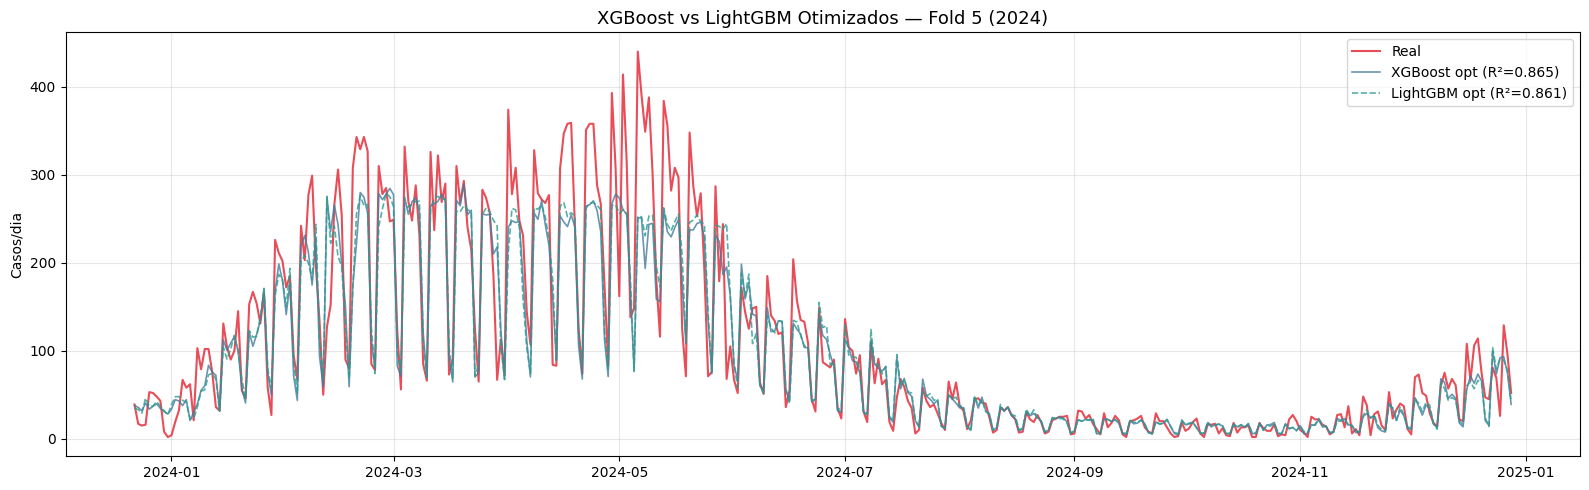

✅ Gráfico, métricas e modelos salvos!


In [7]:
# Visualização comparativa — Fold 5 (2024)
folds_lista = list(tscv.split(X))
train_idx, val_idx = folds_lista[4]

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
datas_val = df['data'].iloc[val_idx]

modelo_xgb_opt.fit(X_train, y_train, verbose=False)
modelo_lgbm_opt.fit(X_train, y_train)

pred_xgb = np.clip(modelo_xgb_opt.predict(X_val), 0, None)
pred_lgbm = np.clip(modelo_lgbm_opt.predict(X_val), 0, None)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(datas_val, y_val.values, color='#e63946', linewidth=1.5, 
        label='Real', alpha=0.9)
ax.plot(datas_val, pred_xgb, color='#457b9d', linewidth=1.2, 
        label=f'XGBoost opt (R²={r2_score(y_val, pred_xgb):.3f})', alpha=0.8)
ax.plot(datas_val, pred_lgbm, color='#2a9d8f', linewidth=1.2, 
        label=f'LightGBM opt (R²={r2_score(y_val, pred_lgbm):.3f})', 
        alpha=0.8, linestyle='--')
ax.set_title('XGBoost vs LightGBM Otimizados — Fold 5 (2024)', fontsize=13)
ax.set_ylabel('Casos/dia')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/fig14_comparacao_xgb_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

# Salvar métricas e modelos
import joblib
comp_df.to_csv('../reports/metricas_modelos_otimizados.csv', index=False)
joblib.dump(modelo_xgb_opt, '../models/xgboost_otimizado.pkl')
joblib.dump(modelo_lgbm_opt, '../models/lightgbm_otimizado.pkl')
print("✅ Gráfico, métricas e modelos salvos!")